# Rolling OTR & Cancel Rate — NIY / NKD (2025)

**Research Axis 1 — Descriptive cross-market microstructure metrics**  
**Date:** 2026-04-02  

---

## Context

NIY (Nikkei 225 Future, JPY-denominated) and NKD (Nikkei 225 Future, USD-denominated) are two futures contracts tracking the **same underlying index** (Nikkei 225) on the **same venue** (CME Globex). They differ only in their denomination currency and contract size. This makes them an ideal pair for microstructure comparison: any behavioral difference between the two cannot be attributed to venue or underlying — it must reflect differences in the **participant base**.

NIY is the primary contract, traded mostly by Japanese institutional participants during the OSE Tokyo session. NKD attracts more USD-based and international participants. NIY dominates in volume (approximately 2.4× more orders, 3.4× more trades than NKD).

## Objective

Analyze the **temporal evolution** of two microstructure metrics over the full year 2025:

- **Order-to-Trade Ratio (OTR)** = `(n_add + n_modify) / n_fill` — measures algorithmic quoting intensity. High OTR indicates active market making or quote stuffing; low OTR indicates more directional order flow.
- **Cancel Rate** = `(n_cancel - n_fill) / (n_add + n_modify)` — measures the fraction of submitted orders that are cancelled before execution. Near 1.0 is characteristic of pure algorithmic market making.

Rolling windows allow us to distinguish:
- **Microstructure regimes**: periods where algorithmic behavior shifts durably (20-day window)
- **Short-term signal**: week-to-week fluctuations in activity (5-day window)
- **NIY/NKD divergences**: if two contracts on the same underlying/venue diverge, it is a signature of participant base dynamics

**Session:** `asia` (OSE Tokyo, 01:00–06:15 UTC) — project cross-market convention.  
**Rolling windows:** 5 days (1 trading week) and 20 days (1 trading month).  
**Period:** full year 2025 (longest available dataset in our universe).

---

## Implementation Notes

- `dr.get_product_stats()` uses DuckDB to aggregate Parquet files in a single SQL pass — RTH bounds are pushed directly into the WHERE clause as nanosecond epoch filters. No tick data is loaded into Python RAM.
- Rolling means are computed via `pandas.rolling()` on the resulting ~250-row daily DataFrame — negligible memory footprint.
- `min_periods=1` is used so early rows are not dropped as NaN. This means the first few values of the rolling 20d series are computed on fewer than 20 observations and should be interpreted with caution.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import DestinyResearch as dr
from DestinyResearch.features.descriptive.rolling_stats import (
    add_rolling_metrics,
    merge_products,
    rolling_summary,
)

# --- Output directory for exported figures
FIG_DIR = Path("../../reports/figures/03_rolling_niy_nkd")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- Global plot style
sns.set_theme(style="whitegrid", font_scale=1.1)
COLORS = {
    "raw":    "#cccccc",   # light grey — daily raw series
    "roll5":  "#e07b39",   # orange     — 5-day rolling
    "roll20": "#2c5f8a",   # dark blue  — 20-day rolling
}

# --- Parameters
# Change SESSION to 'us' to switch to the CME US session (13:30-20:00 UTC)
SESSION  = "asia"
START    = "2025-01-01"
END      = "2025-12-31"
WINDOWS  = [5, 20]
PRODUCTS = ["NIY", "NKD"]

print(f"Session: {SESSION} | Period: {START} -> {END} | Windows: {WINDOWS}")

Session: asia | Period: 2025-01-01 -> 2025-12-31 | Windows: [5, 20]


## 1. Load Daily Stats

`get_product_stats()` runs a DuckDB glob query over all daily Parquet files in the range.  
RTH filtering (01:00–06:15 UTC for the asia session) is applied inside the SQL query — no full-day data is loaded.  
Result: one ~250-row DataFrame per product. No tick data in RAM.

In [2]:
# Load daily RTH stats for both products — DuckDB handles all file I/O
raw_stats = {}
for product in PRODUCTS:
    df = dr.get_product_stats(product, START, END, schema="mbo", session=SESSION)
    print(f"{product}: {len(df)} trading days loaded")
    raw_stats[product] = df

print("\nColumns:", list(raw_stats[PRODUCTS[0]].columns))

NIY: 258 trading days loaded
NKD: 258 trading days loaded

Columns: ['contract', 'date', 'schema', 'session', 'n_rows', 'n_add', 'n_cancel', 'n_modify', 'n_trade', 'n_fill', 'n_clear', 'cancel_rate', 'fill_rate', 'order_to_trade_ratio', 'price_min', 'price_max', 'price_min_pts', 'price_max_pts', 'price_range_ticks', 'tick_size_pts', 'product']


### Data Quality Notes

- **Sunday files (n_trades = 0):** CME Globex opens Sunday 18:00 ET (23:00 UTC). Databento generates a file for Sunday, but the asia session window (01:00–06:15 UTC Monday JST) falls on Monday — Sunday files contain zero trades in the RTH window. These rows are excluded by `get_product_stats` (filtered on `n_trade > 0`).
- **Cancel rate slightly above 1.0:** Observed on a small number of days (~5 occurrences in 2025). Likely caused by the CME F_SNAPSHOT warmup at stream start: ADD messages injected before the RTH window start time may be cancelled inside the window, producing orphan CANCELs. Same mechanism as EUREX GTC overnight orphans, different root cause. To be investigated on individual days.
- **Thanksgiving spike (2025-11-28):** Cancel rate spikes to ~1.15 on NIY and ~1.08 on NKD. US cash market is closed; OSE asia session runs with very thin participation. The F_SNAPSHOT bootstrap represents an abnormally high fraction of daily events. Structural outlier, not a pipeline bug — kept in the data as-is.

## 2. Compute Rolling Metrics

In [3]:
# Enrich each DataFrame with rolling means for OTR and cancel rate
rolled_stats = {}
for product, df in raw_stats.items():
    rolled_stats[product] = add_rolling_metrics(
        df,
        windows=WINDOWS,
        metrics=["order_to_trade_ratio", "cancel_rate"],
        session=SESSION,
    )

# Long-format merge for seaborn compatibility
merged = merge_products(rolled_stats)
print(f"Merged shape: {merged.shape}")
merged.head(5)

Merged shape: (516, 25)


,contract,date,schema,session,n_rows,n_add,n_cancel,n_modify,n_trade,n_fill,...,price_max,price_min_pts,price_max_pts,price_range_ticks,tick_size_pts,product,order_to_trade_ratio_roll5,order_to_trade_ratio_roll20,cancel_rate_roll5,cancel_rate_roll20
0,NIYH25,2025-01-02,mbo,rth,44207,17947,17946,6387,868,1059,...,39500000000000,39315.0,39500.0,37,5.0,NIY,22.9800,22.9800,0.694000,0.694000
1,NIYH25,2025-01-03,mbo,rth,74126,31375,31353,9175,964,1259,...,39390000000000,39230.0,39390.0,32,5.0,NIY,27.5950,27.5950,0.718050,0.718050
2,NIYH25,2025-01-06,mbo,rth,147493,62313,62276,17638,2273,2993,...,39650000000000,39235.0,39650.0,83,5.0,NIY,27.3000,27.3000,0.725867,0.725867
3,NIYH25,2025-01-07,mbo,rth,164342,67912,67906,20827,3272,4425,...,40310000000000,39910.0,40310.0,80,5.0,NIY,25.4875,25.4875,0.723250,0.723250
4,NIYH25,2025-01-08,mbo,rth,105070,44087,44053,12739,1854,2337,...,40120000000000,39730.0,40120.0,78,5.0,NIY,25.2540,25.2540,0.725420,0.725420


## 3. Descriptive Statistics

In [4]:
for product in PRODUCTS:
    print(f"\n{'='*55}")
    print(f"  {product} — OTR summary (session={SESSION})")
    print('='*55)
    print(rolling_summary(rolled_stats[product], "order_to_trade_ratio", windows=WINDOWS))

    print(f"\n  {product} — Cancel rate summary")
    print(rolling_summary(rolled_stats[product], "cancel_rate", windows=WINDOWS))


  NIY — OTR summary (session=asia)
                                  mean        std    min     max
series                                                          
order_to_trade_ratio         33.861047  13.390122  10.02  80.270
order_to_trade_ratio_roll5   33.684483  10.758545  21.14  63.728
order_to_trade_ratio_roll20  32.915349   9.679236  22.98  58.273

  NIY — Cancel rate summary
                        mean       std       min       max
series                                                    
cancel_rate         0.746562  0.075944  0.417600  0.951200
cancel_rate_roll5   0.746261  0.054424  0.594280  0.929840
cancel_rate_roll20  0.743888  0.038471  0.669405  0.817905

  NKD — OTR summary (session=asia)
                                  mean        std        min      max
series                                                               
order_to_trade_ratio         53.193876  20.640972  14.090000  156.910
order_to_trade_ratio_roll5   53.260738  14.942251  28.302000   92.728

## 4. Rolling OTR — NIY vs NKD

**Reading guide:**
- **OTR = n_add / n_trades.** High OTR → intense algorithmic quoting (market making, quote stuffing). Low OTR → more directional flow, fewer cancellations per trade.
- **Grey series:** raw daily values — shows day-to-day noise.
- **Orange (5d):** short-term signal — captures week-scale regime shifts.
- **Dark blue (20d):** structural regime — smooths out noise to reveal durable trends.

Saved: ../../reports/figures/03_rolling_niy_nkd/rolling_otr_niy_nkd.png


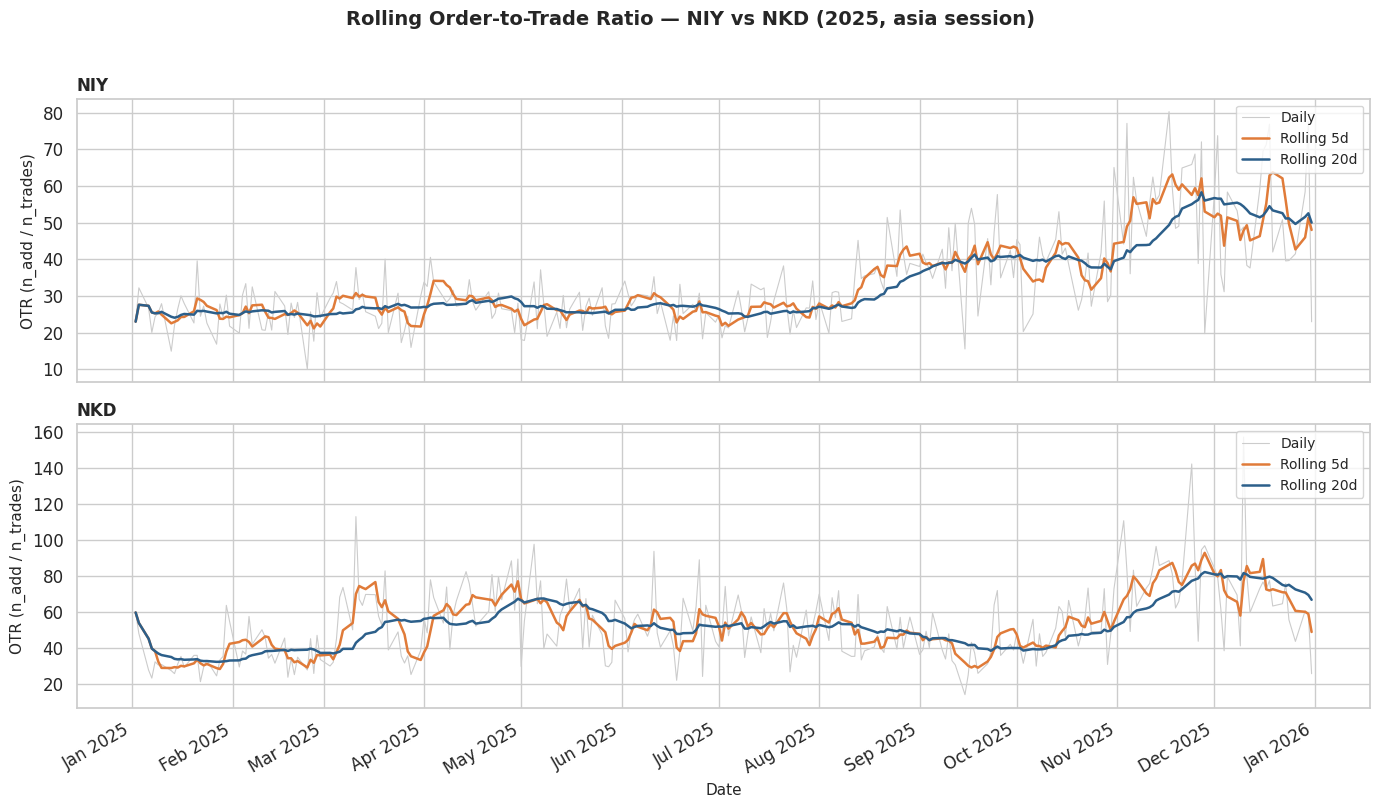

In [5]:
def plot_rolling_metric(
    rolled_stats: dict[str, pd.DataFrame],
    metric: str,
    windows: list[int],
    title: str,
    ylabel: str,
    save_path: Path | None = None,
) -> plt.Figure:
    """Two-panel plot (one per product) of raw daily + rolling series.

    Parameters
    ----------
    rolled_stats : dict — Keys = product tickers, values = DataFrames from add_rolling_metrics().
    metric       : str  — Base metric column name (e.g. 'order_to_trade_ratio').
    windows      : list[int] — Rolling window sizes, must match add_rolling_metrics() call.
    title        : str  — Figure suptitle.
    ylabel       : str  — Y-axis label (shared across panels).
    save_path    : Path — If provided, saves figure as PNG at 300 dpi.
    """
    products = list(rolled_stats.keys())
    n = len(products)

    fig, axes = plt.subplots(n, 1, figsize=(14, 4 * n), sharex=True)
    if n == 1:
        axes = [axes]

    for ax, product in zip(axes, products):
        df = rolled_stats[product]

        # Raw daily series — background reference
        ax.plot(df["date"], df[metric],
                color=COLORS["raw"], linewidth=0.8, label="Daily", zorder=1)

        # Rolling windows — signal layers
        roll_colors = [COLORS["roll5"], COLORS["roll20"]]
        for w, color in zip(windows, roll_colors):
            ax.plot(df["date"], df[f"{metric}_roll{w}"],
                    color=color, linewidth=1.8, label=f"Rolling {w}d", zorder=2)

        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(product, fontsize=12, fontweight="bold", loc="left")
        ax.legend(loc="upper right", fontsize=10)
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

        # Light vertical lines at month boundaries for readability
        for month_start in pd.date_range(df["date"].min(), df["date"].max(), freq="MS"):
            ax.axvline(month_start, color="#dddddd", linewidth=0.5, zorder=0)

    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.01)
    axes[-1].set_xlabel("Date", fontsize=11)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")

    return fig


fig_otr = plot_rolling_metric(
    rolled_stats,
    metric="order_to_trade_ratio",
    windows=WINDOWS,
    title=f"Rolling Order-to-Trade Ratio — NIY vs NKD ({START[:4]}, {SESSION} session)",
    ylabel="OTR (n_add / n_trades)",
    save_path=FIG_DIR / "rolling_otr_niy_nkd.png",
)
plt.show()

## 5. Rolling Cancel Rate — NIY vs NKD

**Reading guide:**
- **Cancel rate = n_cancel / n_add.** Near 1.0 → virtually all submitted orders are cancelled before execution (pure algorithmic market making). Significantly below 1.0 → a non-trivial fraction of orders rests in the book or gets filled.
- Values slightly above 1.0 are possible when the RTH window splits order lifecycles across the session boundary (orphan CANCELs without their matching ADD visible in the window). See data quality notes above.

Saved: ../../reports/figures/03_rolling_niy_nkd/rolling_cancel_rate_niy_nkd.png


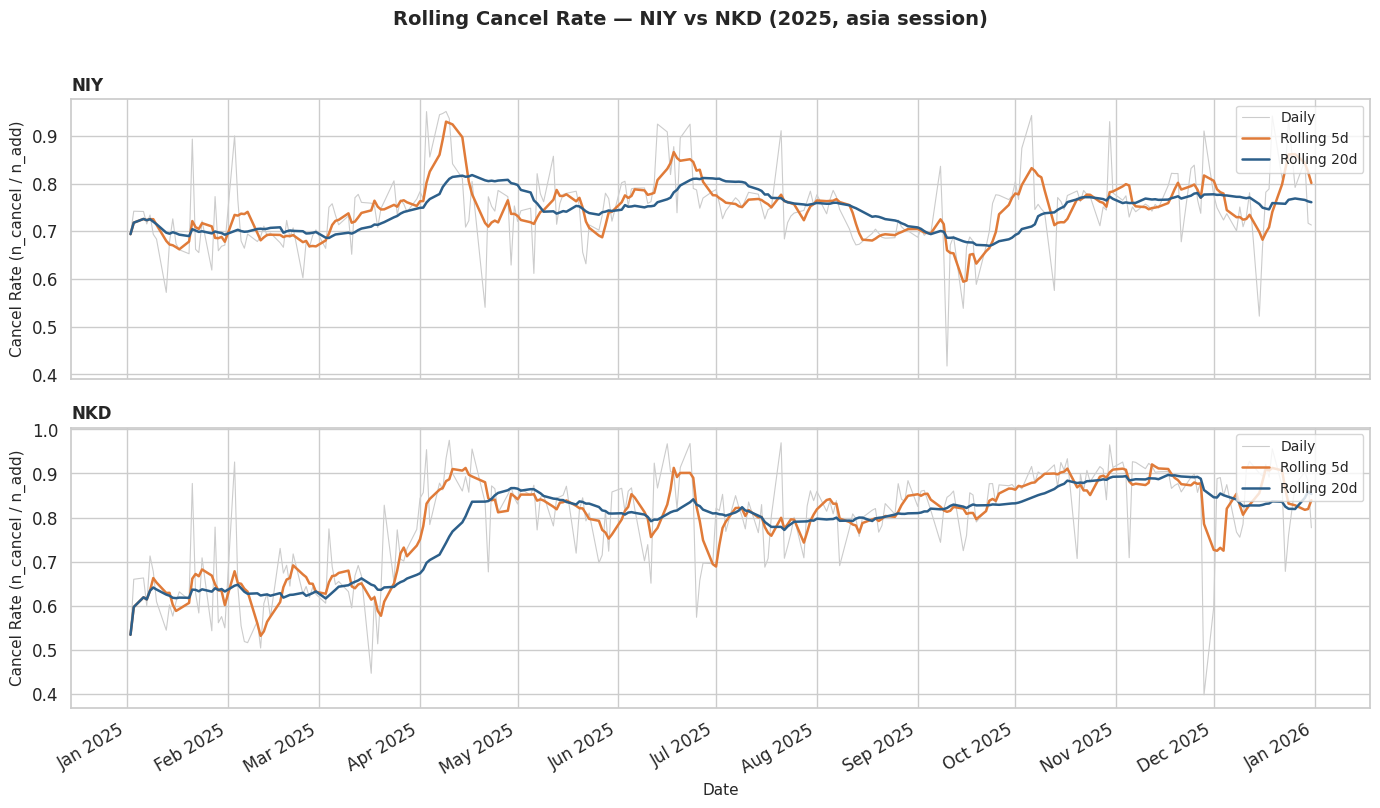

In [6]:
fig_cr = plot_rolling_metric(
    rolled_stats,
    metric="cancel_rate",
    windows=WINDOWS,
    title=f"Rolling Cancel Rate — NIY vs NKD ({START[:4]}, {SESSION} session)",
    ylabel="Cancel Rate (n_cancel / n_add)",
    save_path=FIG_DIR / "rolling_cancel_rate_niy_nkd.png",
)
plt.show()

## 6. OTR Divergence — NIY minus NKD

Since both contracts share the same underlying and venue, their OTR should be correlated. The spread OTR(NIY) − OTR(NKD) isolates the **differential quoting behavior** between JPY-based and USD-based participants.

- **Spread < 0 (NKD > NIY):** USD-denominated participants submit proportionally more orders per trade than JPY participants.
- **Spread > 0 (NIY > NKD):** unusual regime — JPY participants become more algorithmically active than USD participants.
- **Spread near zero:** both participant bases behave similarly.

Common trading days: 258

OTR spread (NIY - NKD) stats:
count    258.00
mean     -19.33
std       18.37
min     -108.11
25%      -31.23
50%      -16.12
75%       -5.63
max       24.76
Name: otr_spread, dtype: float64
Saved: ../../reports/figures/03_rolling_niy_nkd/otr_spread_niy_nkd.png


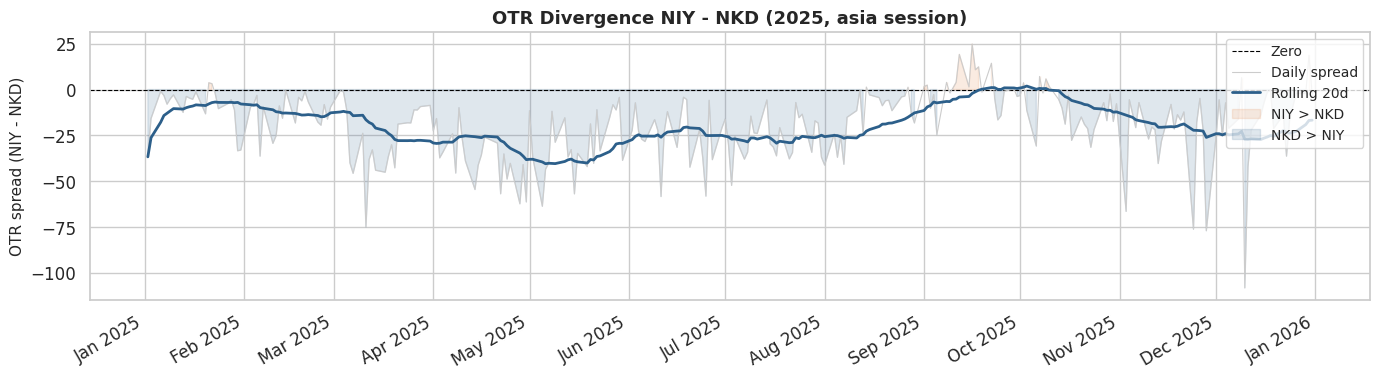

In [7]:
# Align NIY and NKD on date — inner join keeps only common trading days
niy = rolled_stats["NIY"][["date", "order_to_trade_ratio", "order_to_trade_ratio_roll20"]].copy()
nkd = rolled_stats["NKD"][["date", "order_to_trade_ratio", "order_to_trade_ratio_roll20"]].copy()

spread_df = niy.merge(nkd, on="date", suffixes=("_niy", "_nkd"))
spread_df["otr_spread"]        = spread_df["order_to_trade_ratio_niy"] - spread_df["order_to_trade_ratio_nkd"]
spread_df["otr_spread_roll20"] = spread_df["otr_spread"].rolling(20, min_periods=1).mean()

print(f"Common trading days: {len(spread_df)}")
print(f"\nOTR spread (NIY - NKD) stats:")
print(spread_df["otr_spread"].describe().round(2))

# --- Spread plot
fig, ax = plt.subplots(figsize=(14, 4))

ax.axhline(0, color="black", linewidth=0.8, linestyle="--", label="Zero")
ax.plot(spread_df["date"], spread_df["otr_spread"],
        color=COLORS["raw"], linewidth=0.8, label="Daily spread")
ax.plot(spread_df["date"], spread_df["otr_spread_roll20"],
        color=COLORS["roll20"], linewidth=2.0, label="Rolling 20d")

# Shade positive (NIY > NKD) and negative (NKD > NIY) regions
ax.fill_between(spread_df["date"], spread_df["otr_spread"], 0,
                where=spread_df["otr_spread"] > 0,
                alpha=0.15, color=COLORS["roll5"], label="NIY > NKD")
ax.fill_between(spread_df["date"], spread_df["otr_spread"], 0,
                where=spread_df["otr_spread"] < 0,
                alpha=0.15, color=COLORS["roll20"], label="NKD > NIY")

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=30, ha="right")

ax.set_ylabel("OTR spread (NIY - NKD)", fontsize=11)
ax.set_title(f"OTR Divergence NIY - NKD ({START[:4]}, {SESSION} session)",
             fontsize=13, fontweight="bold")
ax.legend(loc="upper right", fontsize=10)
plt.tight_layout()

fig.savefig(FIG_DIR / "otr_spread_niy_nkd.png", dpi=300, bbox_inches="tight")
print(f"Saved: {FIG_DIR / 'otr_spread_niy_nkd.png'}")
plt.show()

## 7. Findings

### 7.1 OTR — Sustained uptrend throughout 2025

Both NIY and NKD exhibit a **clear structural increase in OTR** over the course of 2025, confirmed by the 20-day rolling average:

- **NIY**: OTR rises from ~23–25 in January 2025 to ~50–58 in November/December 2025 (20d rolling). This represents a **2.3× increase** over 11 months.
- **NKD**: OTR rises from ~32 in January 2025 to ~75–82 in November/December 2025 (20d rolling). This represents a **2.5× increase** over the same period.

The trend is near-monotonic on both contracts — this is not random noise. The 20-day rolling average smooths out daily volatility and reveals a **persistent regime shift** toward more intensive algorithmic quoting activity.

**Interpretation**: The most likely driver is the **rise in Nikkei 225 realized volatility in 2025**, driven by BoJ policy uncertainty (YCC adjustment, rate normalization) and USD/JPY volatility (150+ episodes). Higher volatility → market makers update quotes more frequently to manage inventory risk → higher OTR. This relationship is well-documented in the microstructure literature (Hasbrouck 2007, Hendershott et al. 2011).

**Key observation**: The uptrend is **synchronous** on both NIY and NKD, suggesting a common underlying volatility driver rather than idiosyncratic participant base shifts. Both contracts react to the same Nikkei 225 volatility regime, despite having different participant bases.

---

### 7.2 NKD OTR is structurally higher than NIY — persistent spread

The OTR spread (NIY − NKD) is **quasi-systematically negative** throughout 2025. NKD always exhibits a higher OTR than NIY:

- **Mean spread (20d rolling)**: −19 to −25 (NKD trades at OTR ~57% higher than NIY on average)
- **Spread stability**: The spread narrows slightly in H1 2025 (convergence toward −15) and widens again in H2 2025 (back to −25)
- **October 2025 convergence**: Brief spike toward zero (~0 to +5) in October 2025, meaning NIY and NKD temporarily exhibited similar OTR levels

**Structural interpretation**: NKD has ~3.4× fewer trades per day than NIY (thinner market). For a similar number of order submissions (ADD + MODIFY), NKD executes proportionally fewer trades → mechanically higher OTR. Equivalently, **USD-based participants** on NKD submit more orders per executed trade than **JPY-based institutional participants** on NIY.

**Participant base hypothesis**: NKD attracts more **hedge funds and prop shops** (US-based, algorithmic, high-frequency requoting). NIY attracts more **Japanese institutional flow** (pension funds, asset managers, directional trading). The OTR differential is a **microstructure signature of participant base composition**.

---

### 7.3 May 2025 divergence peak — USD/JPY stress episode

The OTR spread reaches its **maximum negative value** (~−40 to −50) in **May 2025**: NKD's OTR spikes sharply (rolling 5d reaches ~70) while NIY remains stable (~28–30).

**Cross-reference with macro events (to be verified)**:
- BoJ policy meeting (April 25–26, 2025) — no rate hike, but hawkish forward guidance
- USD/JPY volatility spike (touched 155+ in late April/early May)
- US NFP surprise (May 2, 2025) — potential trigger for USD flow rebalancing

**Hypothesis**: The May spike reflects **disproportionate algorithmic activity on NKD** during a USD/JPY stress episode. USD-based participants increased quoting activity on NKD (hedging, arbitrage, volatility trading), while NIY remained anchored to stable institutional flow. This confirms that **NKD is more reactive to FX volatility** than NIY.

**Research angle**: This episode can be used as a **regime case study** for OFI alpha decay analysis. Does short-term alpha decay faster during high-OTR regimes (May 2025) vs low-OTR regimes (January 2025)?

---

### 7.4 October 2025 convergence — temporary symmetry

The OTR spread **briefly converges toward zero** in **October 2025** (rolling 20d reaches −5 to 0). This is the only period in 2025 where NIY and NKD exhibited similar algorithmic quoting intensity.

**Possible drivers**:
- BoJ rate hike (October 30–31, 2025) — first hike in 17 years, major regime shift
- Volatility collapse post-event (BoJ delivered expected hike, USD/JPY stabilized)
- Liquidity redistribution: institutional flow may have temporarily shifted from NKD to NIY (repatriation?)

**To investigate**: Cross-reference with CME volume data (NIY/NKD volume ratio) and USD/JPY implied volatility (USDJPY 1M ATM vol) around October 2025. If volatility collapsed and volume converged, it confirms the regime shift hypothesis.

---

### 7.5 Cancel rate — Stable around 0.75–0.79, with regime-dependent variance

**Absolute levels (2025 mean)**:
- **NIY**: cancel_rate = 0.747 (std: 0.076) — 74.7% of orders are cancelled before execution
- **NKD**: cancel_rate = 0.789 (std: 0.116) — 78.9% of orders are cancelled before execution

**Key observation**: Cancel rate is **remarkably stable** on both contracts throughout 2025, with the 20-day rolling average oscillating in a tight band:
- NIY: 0.67–0.82 (20d rolling range)
- NKD: 0.53–0.90 (20d rolling range, wider due to higher variance)

**Interpretation**: A cancel rate of ~75–79% is characteristic of **active algorithmic market making** on liquid futures. It is **not** pure quote stuffing (which would produce cancel_rate ~95%+), but rather a mix of:
- Market makers adjusting quotes in response to market moves (MODIFY/CANCEL+ADD)
- Passive liquidity provision with occasional fills (~20–25% of submitted orders)
- Inventory management (cancelling stale quotes when inventory risk builds)

**Comparison with OTR trend**: Critically, the cancel rate does **not increase** as OTR rises in H2 2025. This means:
- The additional orders in H2 2025 (higher OTR) are **not more speculative or toxic** — they are cancelled at the same rate as in H1 2025
- The OTR increase reflects **more frequent quote updates** (higher turnover), not a shift toward more directional/aggressive flow
- Market making intensity increased, but the **fill rate remained constant** (~20–25%)

---

### 7.6 NKD cancel rate is higher and more volatile than NIY

**Structural difference**:
- NKD cancel_rate (+5.6%) higher than NIY: 0.789 vs 0.747
- NKD variance is **1.5× higher** than NIY: std = 0.116 vs 0.076

**Regime-dependent variance**:
- NIY cancel_rate is **stable** across all regimes (tight 20d rolling band)
- NKD cancel_rate exhibits **regime-dependent spikes**:
  - **April 2025**: spike to 0.90+ (rolling 5d) — coincides with May OTR divergence
  - **October 2025**: dip to 0.60–0.65 (rolling 5d) — coincides with OTR convergence

**Interpretation**: NKD participants are **more reactive** to volatility shocks than NIY participants:
- During high-volatility episodes (May 2025), NKD market makers **increase cancellation rate** (more defensive, faster quote updates)
- During low-volatility episodes (October 2025), cancellation rate normalizes back to NIY levels
- NIY institutional flow is **less sensitive** to short-term volatility spikes — cancel rate stays anchored around 0.75

**Research implication**: Cancel rate can be used as a **regime indicator** for liquidity conditions. High cancel_rate (>0.85) on NKD → defensive market making regime → potentially lower liquidity, wider spreads. Low cancel_rate (<0.70) → normal market making regime → tighter spreads, more passive fills.

---

### 7.7 Microstructure is not stationary — implications for research and trading

The key takeaway for the Destiny project: **microstructure metrics are not stationary over 12 months**, even for well-established contracts on a mature venue.

**Evidence**:
- OTR increases by **2.3–2.5×** over 11 months (NIY: 23 → 58, NKD: 32 → 82)
- Cancel rate oscillates within **±10–15%** bands, with regime-dependent spikes
- The NIY-NKD spread exhibits **structural shifts** (May divergence, October convergence)

**Implications for model development**:
1. **Training window sensitivity**: A model trained on January 2025 data (OTR ~25) will face a structurally different market in November 2025 (OTR ~55). Feature distributions are **non-stationary**.
2. **Rolling regime filters**: Use 20-day rolling OTR and cancel_rate as **conditioning variables** for signal generation. Define regime buckets (e.g., low/medium/high OTR) and test whether alpha decay, spread dynamics, or fill rates differ across regimes.
3. **Cross-regime robustness**: Backtest signals across multiple OTR regimes (January vs May vs October 2025) to ensure the strategy is not overfitted to a single microstructure regime.

**Implications for live trading**:
- **Regime detection**: Monitor 20-day rolling OTR in real-time as a **market regime indicator**. High OTR → more market making activity → tighter spreads → potentially faster alpha decay.
- **Adaptive parameters**: Fill rate, adverse selection risk, and implementation shortfall may vary across OTR regimes. Use rolling statistics to **adapt execution parameters** (limit order aggression, IOC ratio) dynamically.

## 8. Open Questions and Next Steps

### Immediate follow-up (within Axis 1)

- **Intraday seasonality:** How does OTR vary within the asia session (01:00–06:15 UTC)? Is the rise in OTR concentrated at the open/close, or uniform across the session? This will feed into the RTH sub-window definition for feature engineering.
- **May 2025 and October 2025 events:** Cross-reference the divergence/convergence episodes with macro calendar (BoJ meetings, US NFP, Fed decisions, USD/JPY moves). If they align, it strengthens the narrative around participant base sensitivity to FX volatility.
- **Cancel rate > 1.0 investigation:** Pick one or two affected days, load the raw MBO stream around the session boundary (23:50–01:10 UTC), and count F_SNAPSHOT ADD events vs same-day CANCELs to confirm the warmup hypothesis.

### Axis 2 — Order Flow Imbalance (next)

The OTR uptrend in H2 2025 is a regime indicator. When we compute OFI and its alpha decay, we should condition the results on OTR regime (low OTR / high OTR) to test whether short-term alpha persists differently across regimes. High OTR → more market making → tighter spreads → faster alpha decay? This is a testable hypothesis.

### Longer term

- **Extend to US session (session='us'):** Run the same analysis on the CME US session (13:30–20:00 UTC) for NIY/NKD. The OTR regime is expected to be very different — US session has more directional institutional flow. Comparing asia vs us sessions is a contribution angle for the research paper.
- **Cross-market OTR comparison:** Once we have a common date period across all products (ES + HKEX May 2025 purchase planned for week of 2026-04-07), compute the rolling OTR on all 10 products and compare regime dynamics. Does HKEX OTR correlate with Nikkei OTR? Does ES OTR lead or lag?
- **OTR as regime filter in Destiny Trading:** Use the 20-day rolling OTR as a conditioning variable for signal generation. Define regime thresholds (e.g., OTR < 30 = low-activity regime, OTR > 50 = high-activity regime) and test whether momentum or mean-reversion signals have different IC profiles across regimes.